## Часть 1. Настройка данных и обучение модели
-----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('~//Documents//University//Анализ данных//'
                 '1. ML Course ipynb//08-Linear-Regression-Models//Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Исследую зависимость каждого признака на целевую переменную (sales)

### Вариант с корреляцией

<Axes: >

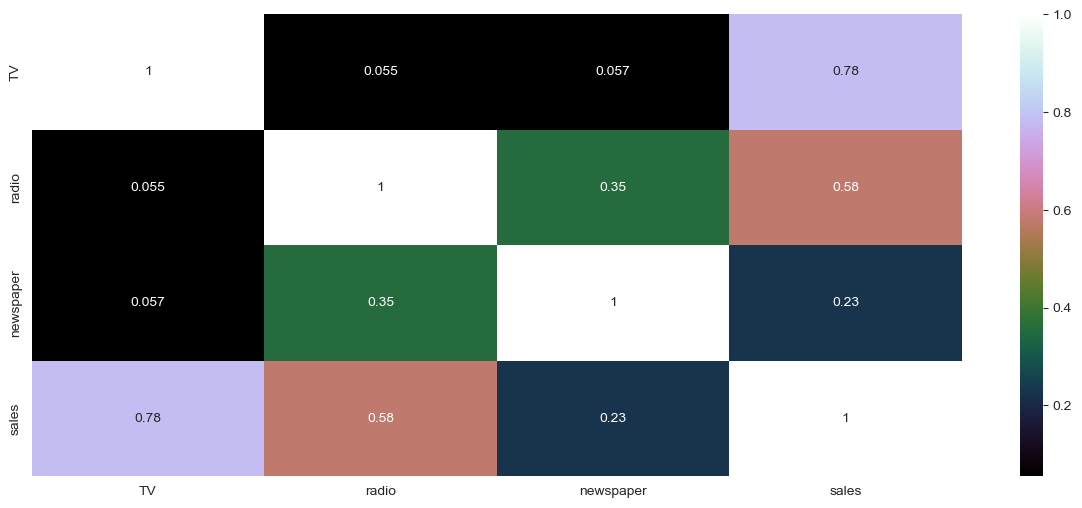

In [3]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.corr(), annot=True, cmap='cubehelix')

### Вариант с ScatterPlot

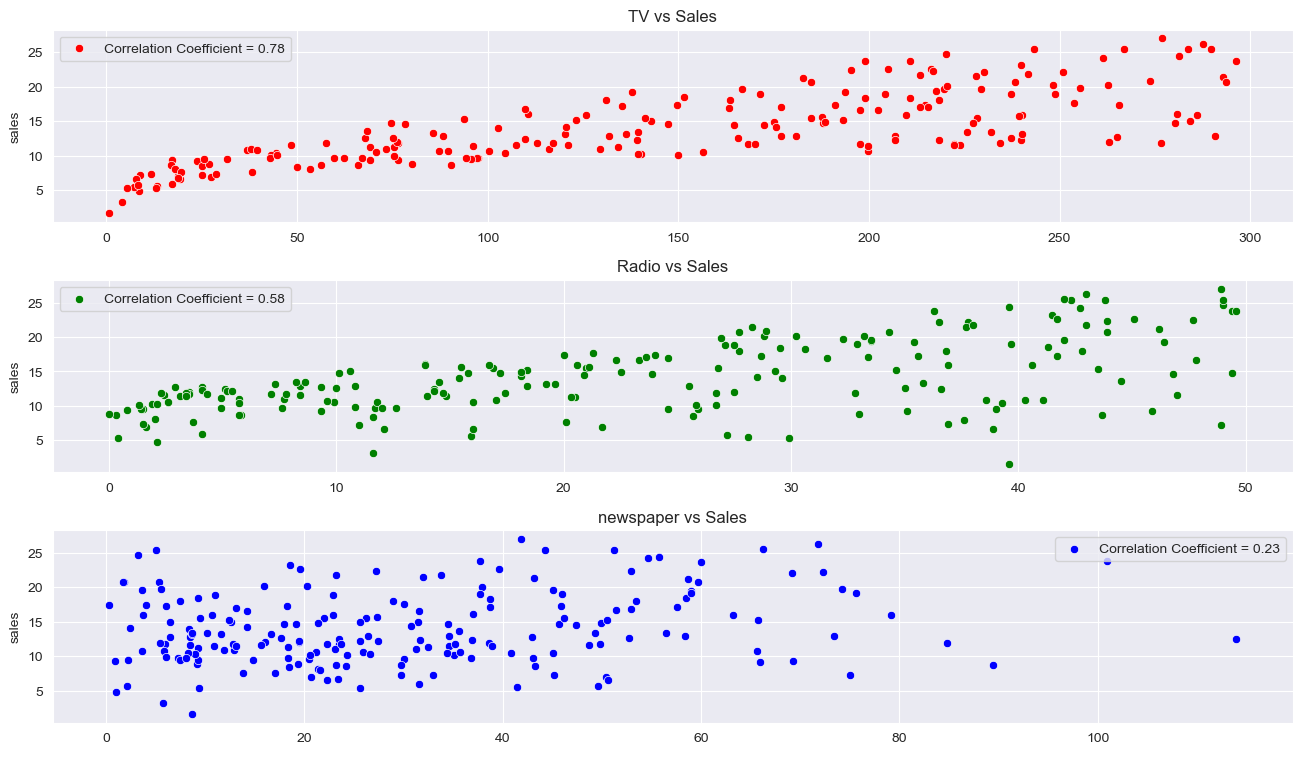

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(16,9))

ax[0].set_title('TV vs Sales')
ax[0].set_xlabel(' ')
sns.scatterplot(df,
                x=df['TV'],
                y=df['sales'],
                ax=ax[0],
                color='r',
                label=f'Correlation Coefficient = {df['TV'].corr(df['sales']).round(2)}')

ax[1].set_title('Radio vs Sales')
ax[1].set_xlabel(' ')
sns.scatterplot(df,
                x=df['radio'],
                y=df['sales'],
                ax=ax[1],
                color='g',
                label=f'Correlation Coefficient = {df['radio'].corr(df['sales']).round(2)}')

ax[2].set_title('newspaper vs Sales')
ax[2].set_xlabel(' ')
sns.scatterplot(df,
                x=df['newspaper'],
                y=df['sales'],
                ax=ax[2],
                color='b',
                label=f'Correlation Coefficient = {df['newspaper'].corr(df['sales']).round(2)}')

plt.subplots_adjust(hspace=0.3)

### Вариант в sns.pairplot()

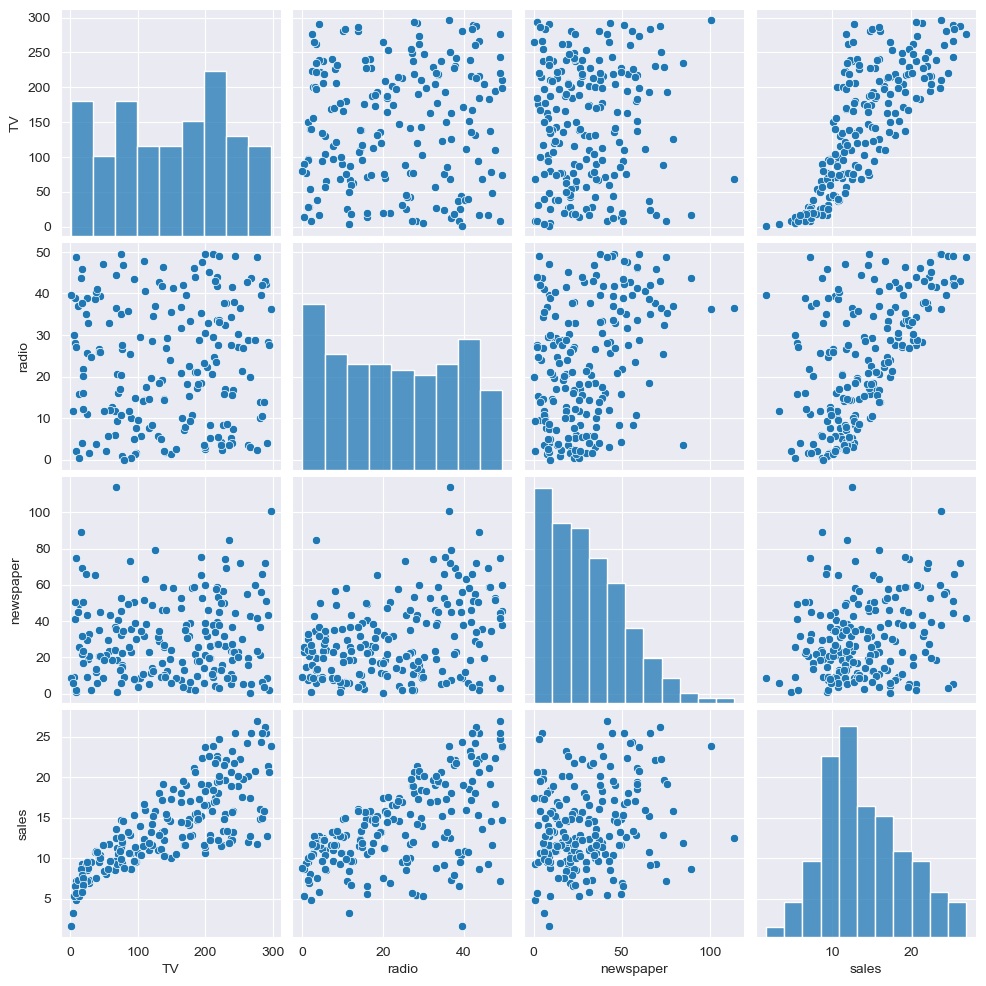

In [5]:
sns.pairplot(df)

## Разбиваю данные на признаки (features) и целевую переменную (target)

In [6]:
X = df.drop('sales', axis=1) # Features
y = df['sales'] # Target

In [7]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [8]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

## Разбиение данных на обучающую (train) и тестовую (test) выборку

In [9]:
from sklearn.model_selection import train_test_split
help(train_test_split) # Хорошая дока

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value is set to the
        com

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3, # Какой процент данных отнести в тестовую выборку
                                                    random_state=42 # Аналог random.seed для воспроизведения результатов
                                                    )
'Почему тут заходит речь про случайность?'
'Дело в том, что данные перемешиваются случайным образом.';

In [11]:
print(f'Длинна исходных данных = {len(df)},\nДлинна обучающей выборки (70%) = {len(X_train)}')

Длинна исходных данных = 200,
Длинна обучающей выборки (70%) = 140


## Создание модели Линейной регрессии

In [12]:
from sklearn.linear_model import LinearRegression
help(LinearRegression) # При использовании любой модели рекомендуется читать документацию!

Help on class LinearRegression in module sklearn.linear_model._base:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)
 |
 |  Ordinary least squares Linear Regression.
 |
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |
 |  n_jobs : int, default=None
 |      The number of jobs to use for the computation. This will only provide
 |      speedu

In [13]:
model = LinearRegression() # Создаем экземпляр класса модели Линейной регрессии

In [14]:
model.fit(X_train, y_train) # Обучение модели

LinearRegression()

## Часть 2. Оценка работы модели и предсказания
-----

In [15]:
test_predictions = model.predict(X_test) # Предсказание модели для указанных признаков (Из тестовой выборки)
test_predictions

array([16.5653963 , 21.18822792, 21.55107058, 10.88923816, 22.20231988,
       13.35556872, 21.19692502,  7.35028523, 13.27547079, 15.12449511,
        9.01443026,  6.52542825, 14.30205991,  8.97026042,  9.45679576,
       12.00454351,  8.91549403, 16.15619251, 10.29582883, 18.72473553,
       19.76821818, 13.77469028, 12.49638908, 21.53501762,  7.60860741,
        5.6119801 , 20.91759483, 11.80627665,  9.08076637,  8.51412012,
       12.17604891,  9.9691939 , 21.73008956, 12.77770578, 18.1011362 ,
       20.07590796, 14.26202556, 20.93826535, 10.83938827,  4.38190607,
        9.51332406, 12.40486324, 10.17045434,  8.09081363, 13.16388427,
        5.2243552 ,  9.28893833, 14.09330719,  8.69024497, 11.66119763,
       15.71848432, 11.63156862, 13.35360735, 11.1531472 ,  6.33636845,
        9.76157954,  9.4195714 , 24.25516546,  7.69519137, 12.15317572])

### Оцениваем работу модели по метрикам
1. MAE - Средняя абсолютная ошибка
2. MSE - Среднеквадратическая ошибка
3. RMSE - Среднеквадратическое отклонение

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [17]:
df['sales'].mean()

14.0225

In [18]:
'Насколько в среднем модель отклоняется от истинных значений'
mean_absolute_error(y_test, test_predictions)

1.5116692224549093

In [19]:
mean_squared_error(y_test, test_predictions)

3.7967972367152245

In [20]:
'Насколько хорошо себя ведет модель для некоторых плохих точек'
root_mean_squared_error(y_test, test_predictions)

1.9485372043446398

## Часть 3. Анализ остатков (Residuals)
-----
Насколько хорошо в данной задаче подойдет модель Линейной регрессии?

In [21]:
test_residuals = y_test - test_predictions

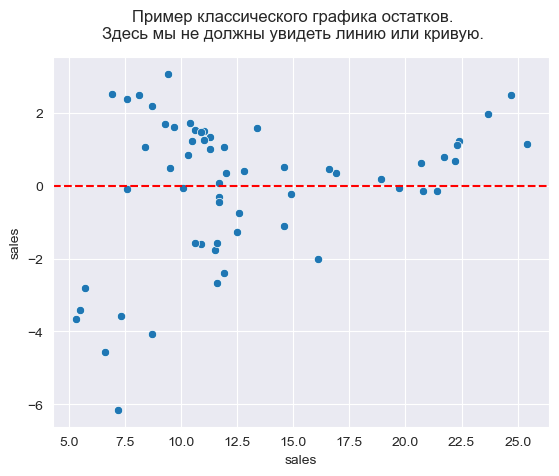

In [22]:
sns.scatterplot(x=y_test, y=test_residuals)
plt.axhline(y=0, c='r', linestyle='--')
plt.suptitle("Пример классического графика остатков.\nЗдесь мы не должны увидеть линию или кривую.");

<Axes: xlabel='sales', ylabel='Count'>

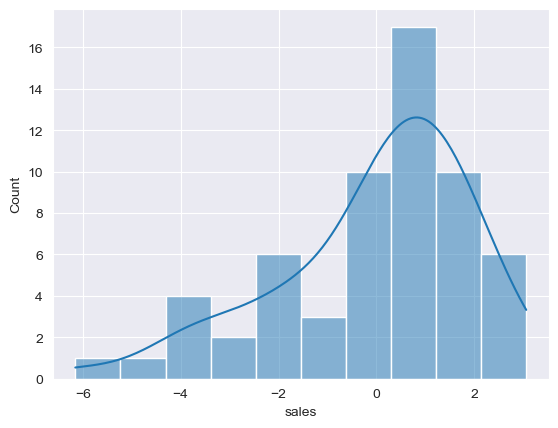

In [23]:
'Тут должно быть распределение, близкое к нормальному'
sns.histplot(x=test_residuals, bins=10, kde=True)

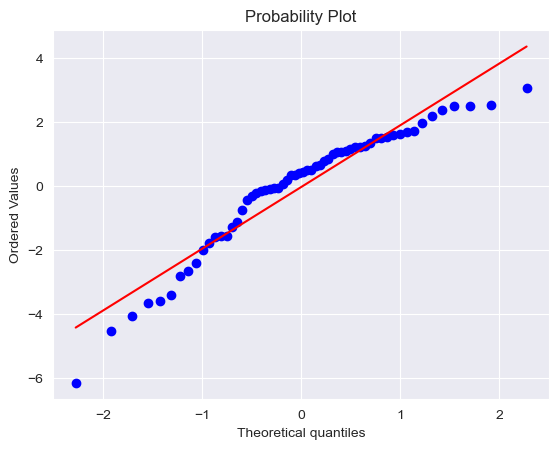

In [24]:
'Если на гистограмме не понятно, насколько распределение близко к нормальному, то можно построить идеальное нормальное распределение'
from scipy.stats import probplot

fig, ax = plt.subplots()
probplot(test_residuals, plot=ax);

## Часть 4. Внедрение модели и интерпретация коэффициентов
-----

Задача:
1. Обучить модель на всех данных (train + test)
2. Сохранить модель
3. Применить её к новым данным

In [25]:
final_model = LinearRegression()
final_model.fit(X, y)

LinearRegression()

In [27]:
'Интерпретация коэффициентов'
print(final_model.coef_, final_model.intercept_)

'При увеличении значения 1 признака на 1 ед. мы можем ожидать увеличение целевой переменной на 0.45 ед.'

[ 0.04576465  0.18853002 -0.00103749] 2.9388893694593996


### Пример хорошей визуализации работы модели
Такой подход визуализации лучше применять только к 3 признакам, если их больше, то разброс будет больше.

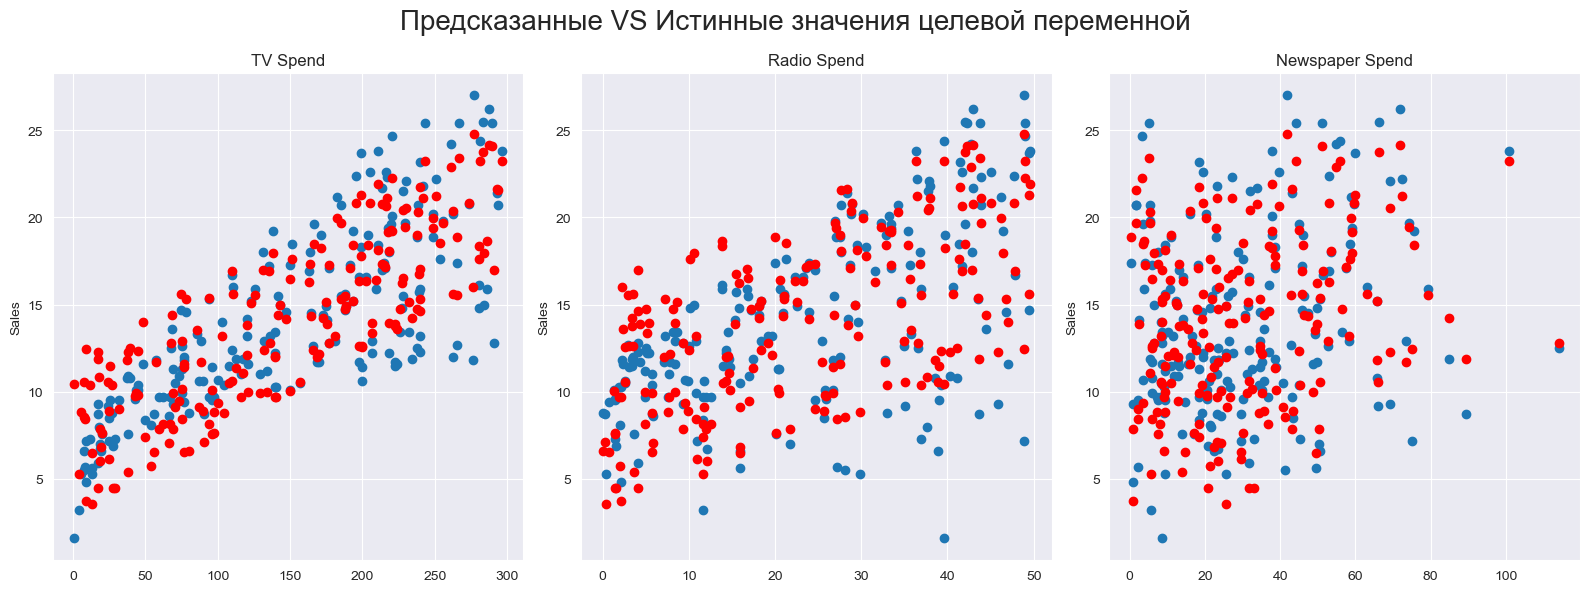

In [31]:
y_hat = final_model.predict(X)

fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))
fig.suptitle('Предсказанные VS Истинные значения целевой переменной', fontsize=20)
axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'o',color='red')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'o',color='red')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'],y_hat,'o',color='red')
axes[2].set_title("Newspaper Spend")
axes[2].set_ylabel("Sales")
plt.tight_layout();

### Сохранение модели

In [32]:
from joblib import dump, load

In [33]:
'Сохранение в файл'
dump(final_model,'final_sales_model.joblib')

['final_sales_model.joblib']

In [34]:
'Загрузка модели'
loaded_model = load('final_sales_model.joblib')

loaded_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

Теперь эту обученную модель можно применять к новым данным.

ВАЖНО! Новые данные должны быть в той же размерности, что и данные, на которых модель обучалась.

In [35]:
'149 TV, 22 Radio, 12 Newspaper'
campaign = [[149, 22, 12]]

In [36]:
loaded_model.predict(campaign)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032])